# EDA & Visualization: Employee Attrition

# import & load

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = "../data/employee_attrition_2026_master.csv"
df = pd.read_csv(data)
df.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


# checking data

ข้อมูล:45,000แถว   29 คอลัมน์

In [19]:
# ตรวจสอบ Missing Value
print(df.isnull().sum().sum())
df.describe().T

0


,count,mean,std,min,25%,50%,75%,max
age,45000.0,34.240711,8.547373,20.0,28.0,34.0,40.0,64.0
is_manager,45000.0,0.242044,0.428326,0.0,0.0,0.0,0.0,1.0
tenure_years,45000.0,3.598353,2.545593,0.1,1.7,3.0,4.8,25.0
salary_usd,45000.0,115385.533333,50084.707992,35000.0,75000.0,103000.0,146000.0,345000.0
salary_vs_market_pct,45000.0,-1.940573,9.990708,-35.0,-8.7,-2.0,4.8,35.0
rto_mandate,45000.0,0.422444,0.493954,0.0,0.0,0.0,1.0,1.0
days_in_office_required,45000.0,3.000022,1.578040,0.0,2.0,3.0,4.0,5.0
commute_minutes,45000.0,35.809444,25.334550,0.0,17.0,30.0,48.0,180.0
prefers_remote,45000.0,0.680800,0.466172,0.0,0.0,1.0,1.0,1.0
flexibility_importance,45000.0,2.994956,1.415595,1.0,2.0,3.0,4.0,5.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 45000 non-null  object 
 1   age                         45000 non-null  int64  
 2   generation                  45000 non-null  object 
 3   gender                      45000 non-null  object 
 4   department                  45000 non-null  object 
 5   job_level                   45000 non-null  object 
 6   is_manager                  45000 non-null  int64  
 7   tenure_years                45000 non-null  float64
 8   salary_usd                  45000 non-null  int64  
 9   salary_vs_market_pct        45000 non-null  float64
 10  work_arrangement            45000 non-null  object 
 11  rto_mandate                 45000 non-null  int64  
 12  days_in_office_required     45000 non-null  int64  
 13  commute_minutes             450

จำนวน Missing Value รวม  0  
employee_id ซ้ำ: 0  
แถวซ้ำทั้งแถว (ไม่นับ id): 0  

###  สัดส่วนพนักงานที่ลาออก (Attrition)

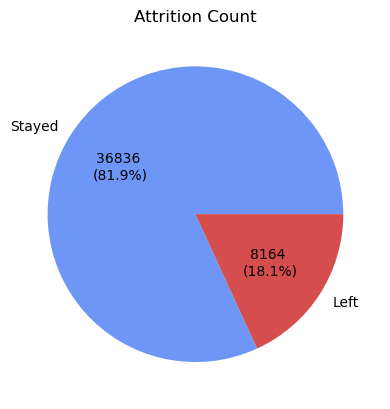

จำนวนพนักงานที่ไม่ลาออก 36836 คน
จำนวนพนักงานที่ลาออก 8164 คน


In [21]:
attr_counts = df['attrition'].value_counts().sort_index()


plt.pie(
    attr_counts,
    labels=['Stayed', 'Left'],
    colors=["#6D96F7", "#CD2A2AD5"],
    autopct=lambda p: f'{int(round(p * sum(attr_counts) / 100))} \n({p:.1f}%)'
)

plt.title("Attrition Count")
plt.ylabel('')
plt.show()

print(f"จำนวนพนักงานที่ไม่ลาออก {attr_counts[0]} คน")
print(f"จำนวนพนักงานที่ลาออก {attr_counts[1]} คน")

**Insight:**  
พนักงานส่วนใหญ่ยังอยู่ 35,508 คน  81.9% (attrition=0)  
มีคนลาออก 7,931 คน 18.1%  (attrition=1) เป็นส่วนน้อย  
ข้อมูลจึงไม่สมดุล (imbalanced)

###  เหตุผลที่ลาออก 

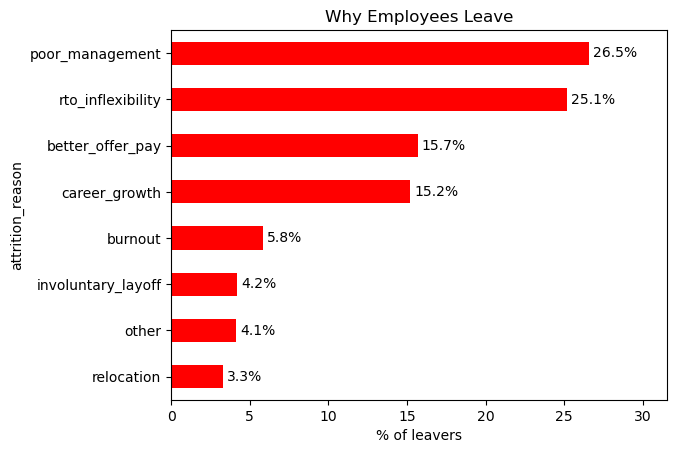

In [22]:
reason = df[df['attrition'] == 1]['attrition_reason'].value_counts(normalize=True) * 100
ax = reason.sort_values().plot(kind='barh', color='r',)
ax.bar_label(ax.containers[0]
             , fmt='%.1f%%'
             , padding=3,)
ax.set_xlim(0, reason.max() + 5)
# plt.tight_layout()
plt.xlabel('% of leavers')
plt.title('Why Employees Leave')
plt.show()


**Insight**
- เหตุผลอันดับ 1 คือ การจัดการที่แย่ 26.5% และอันดับ 2 ความไม่ยืดหยุ่น 25.1% 
- และค่าตอบแทนที่ดีกว่า (15.7%) และการเติบโตในสายงาน (15.2%)
- หมดไฟ (5.8%), ถูกเลิกจ้าง (4.2%), อื่น ๆ (4.1%), ย้ายที่อยู่ (3.3%) เป็นสาเหตุรอง
- สาเหตุหลัก 4 อันดับแรก (82%) เป็นสิ่งที่องค์กร จัดการได้ ไม่ใช่ปัจจัยภายนอก

### Correlation Heatmap

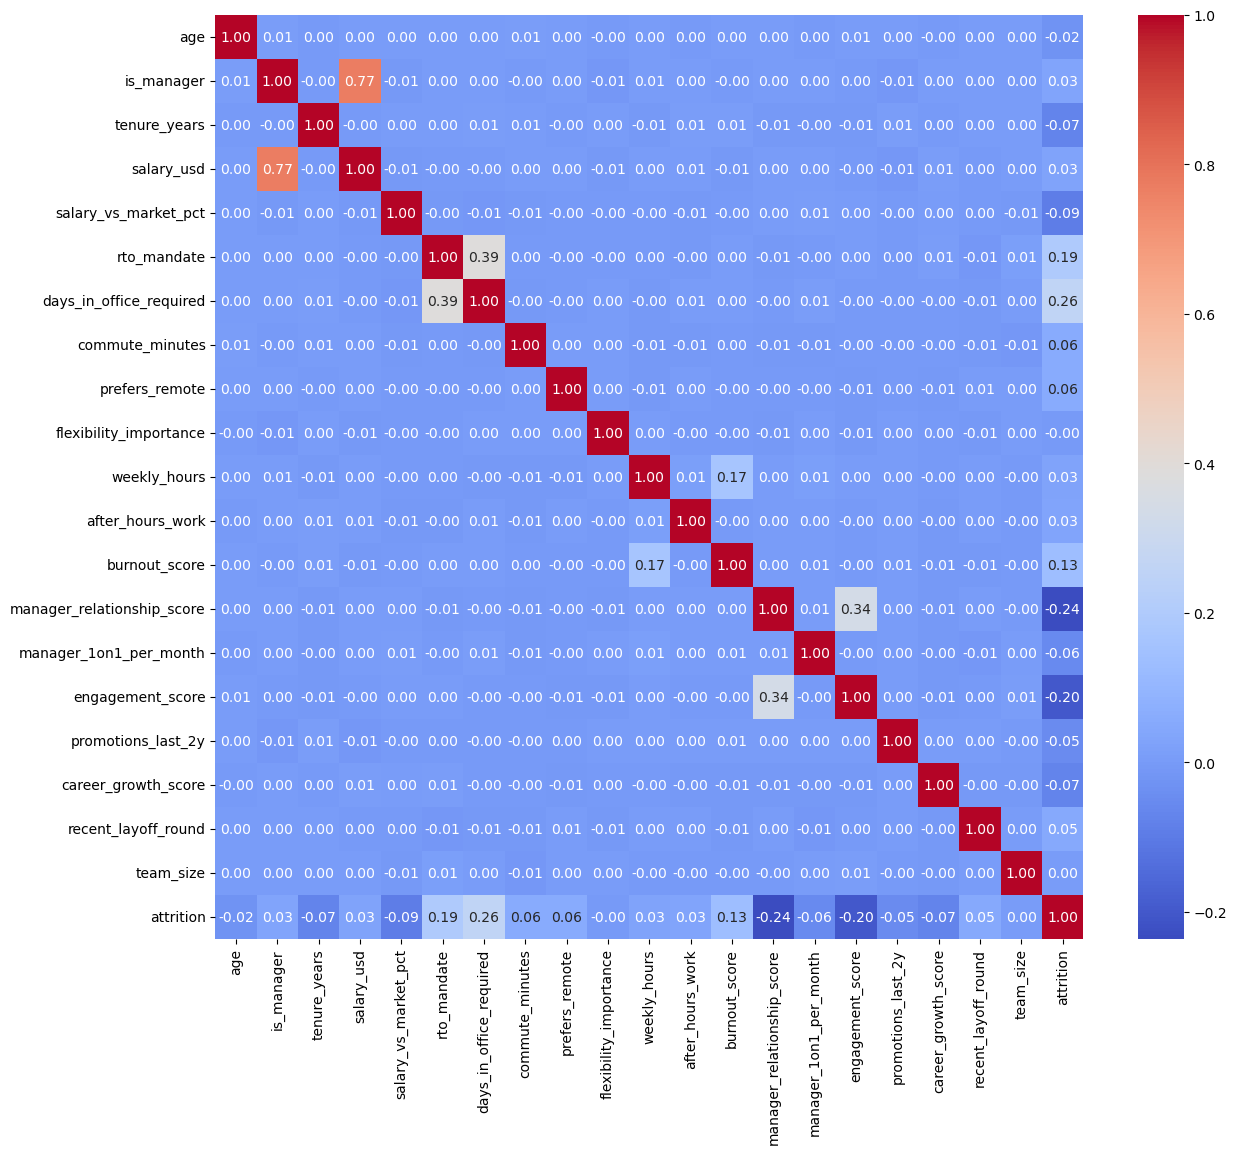

In [23]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)
plt.show()

### Correlation with Attrition bar chart

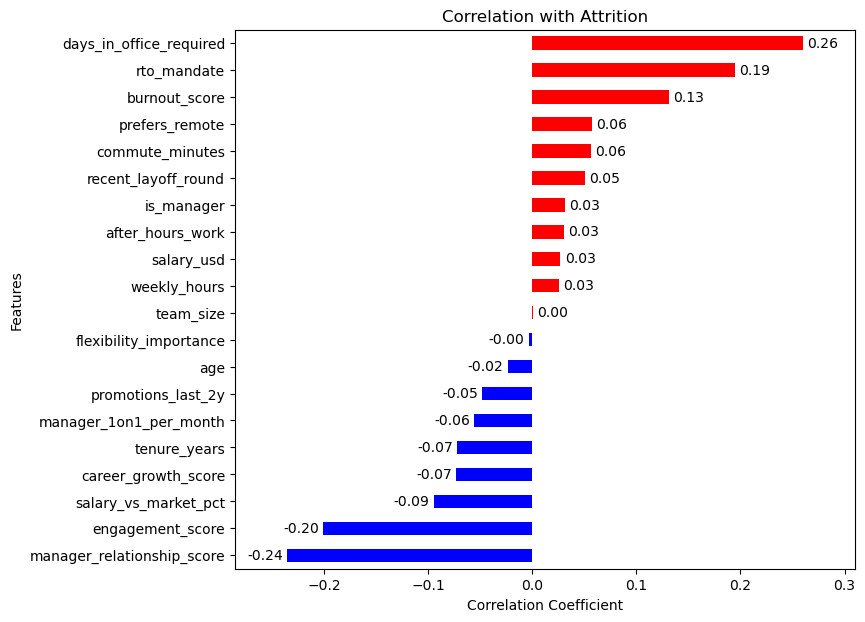

In [24]:
corr_target = df.corr(numeric_only=True)['attrition'].drop('attrition').sort_values()
ax = corr_target.plot(kind='barh', figsize=(8,7), color=['red' if v>0 else 'blue' for v in corr_target] )
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
ax.set_xlim(corr_target.min() - 0.05, corr_target.max() + 0.05)
plt.title("Correlation with Attrition")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

**Insight** 
จากกราฟแสดงได้ว่า ปัจจัยที่ส่งผลต่อการลาออกของพนักงานแบ่งออกเป็น

แท่งสีแดง = ตัวแปรที่ยิ่งสูงยิ่งลาออกเยอะ เช่น work_arrangement_onsite, burnout_score  
แท่งสีน้ำเงิน = ตัวแปรที่ยิ่งสูงยิ่งลาออกน้อย เช่น manager_relationship_score, engagement_score


### กราฟกลุ่มที่อัตราลาออกสูงสุด 5 อันดับแรก

### 1.days_in_office_required (วันที่ต้องอยู่ในออฟฟิศ) กับ Attrition

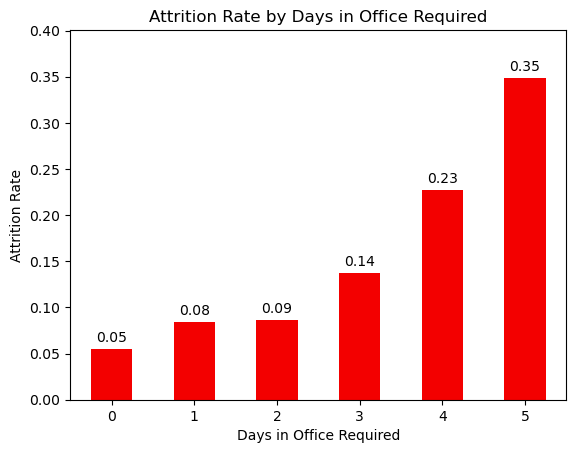

In [25]:
ax = df.groupby('days_in_office_required')['attrition'].mean().plot(kind='bar', color="#F30000")
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.title("Attrition Rate by After-Hours Work")

ax.margins(y=0.15) 

plt.title("Attrition Rate by Days in Office Required") # ปรับชื่อให้ตรงกับข้อมูล
plt.xticks(rotation=0)
plt.xlabel("Days in Office Required")                  # ปรับชื่อให้ตรงกับข้อมูล
plt.ylabel("Attrition Rate")
plt.show()

**Insight:** 

### 2. rto_mandate  ( วันที่ถูกเรียกเขา office ) กับ Attrition

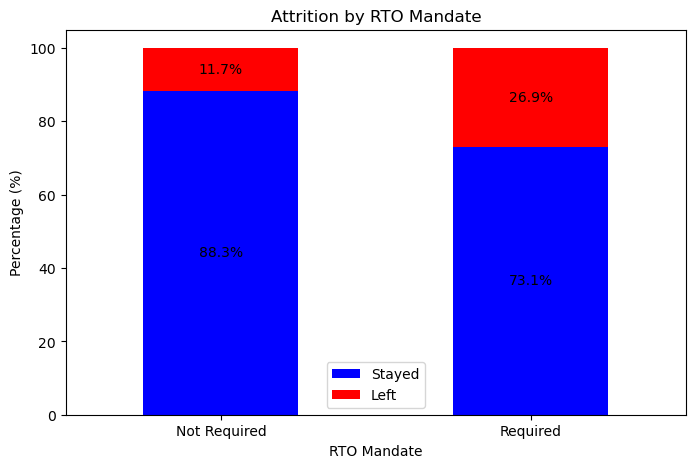

In [45]:
ct = pd.crosstab(
    df['rto_mandate'],
    df['attrition'],
    normalize='index'
) * 100

ax = ct.plot(
    kind='bar',
    stacked=True,
    color=['blue', 'red'],
    figsize=(8, 5)
)

# ใส่ตัวเลขบนแท่ง
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )
    
plt.title('Attrition by RTO Mandate')
plt.xlabel('RTO Mandate')
plt.ylabel('Percentage (%)')
plt.legend(['Stayed', 'Left'])
ax.set_xticklabels(['Not Required', 'Required'], rotation=0)

plt.show()

**Insight:** 

### 3. Burnout Score กับ Attrition

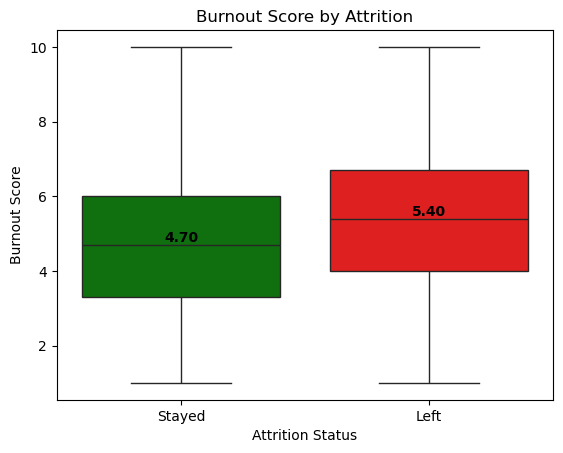

In [ ]:
sns.boxplot(
    x='attrition',
    y='burnout_score',
    data=df,
    hue='attrition',
    palette=['green', 'red'],
    legend=False
)

plt.title("Burnout Score by Attrition")

plt.xticks([0, 1], [
    f"Stayed (n={sum(df['attrition'] == 0)})",
    f"Left (n={sum(df['attrition'] == 1)})"
])

plt.xlabel("Attrition Status")
plt.ylabel("Burnout Score")

plt.show()

**Insight:** 

### 4.Prefers remote (อายุงาน) กับ Attrition 

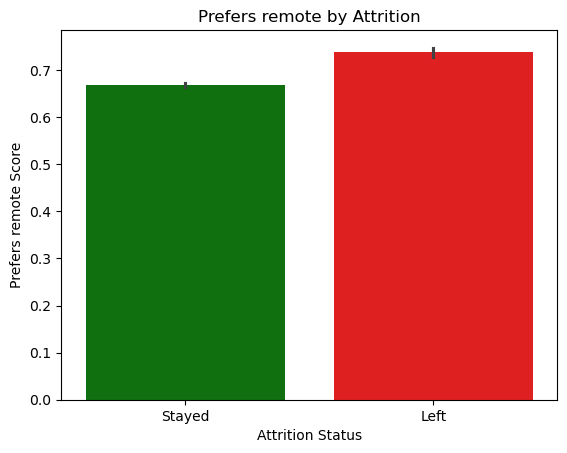

In [28]:
sns.barplot(x='attrition', y='prefers_remote', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("Prefers remote by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Prefers remote Score")
plt.show()

**Insight:**

### 5.Commute (การเดินทาง) กับ Attrition

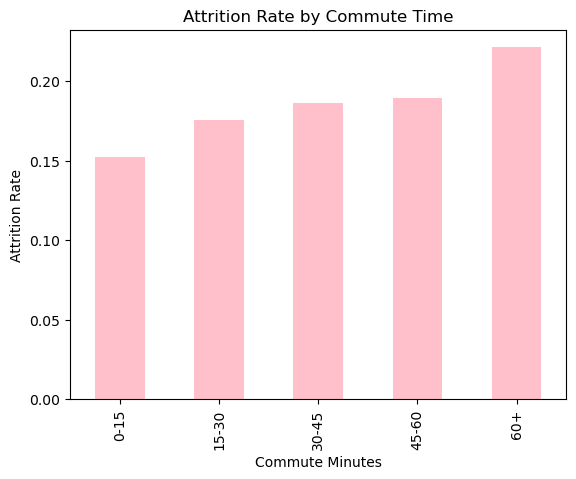

In [29]:
df['commute_bin'] = pd.cut(df['commute_minutes'], bins=[0,15,30,45,60,200],labels=['0-15','15-30','30-45','45-60','60+'])
df.groupby('commute_bin', observed=True)['attrition'].mean().plot(kind='bar', color='pink')
plt.title("Attrition Rate by Commute Time")
plt.ylabel("Attrition Rate")
plt.xlabel("Commute Minutes")
plt.show()

**Insight:** 

### กราฟอัตราการลาออกน้อยที่สุด 5 อันดับ

### 1. Manager relationship (คะแนนความสัมพันธ์ระหว่างหัวหน้างานกับพนักงาน) กับ Attrition

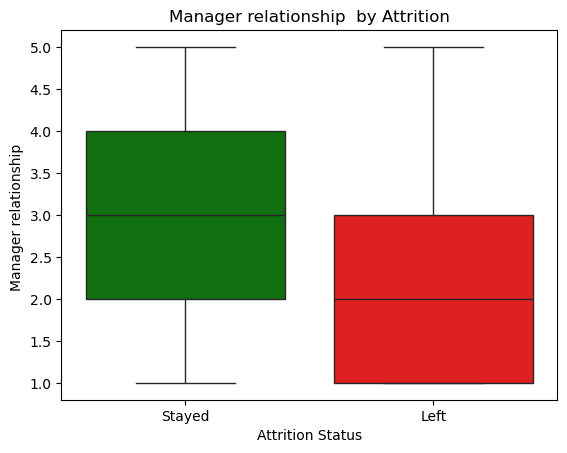

In [30]:
sns.boxplot(x='attrition', y='manager_relationship_score', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("Manager relationship  by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Manager relationship ")
plt.show()

**Insight:** 

### 2.Engagement Score ( คะแนนความผูกพันธ์ ) กับ Attrition

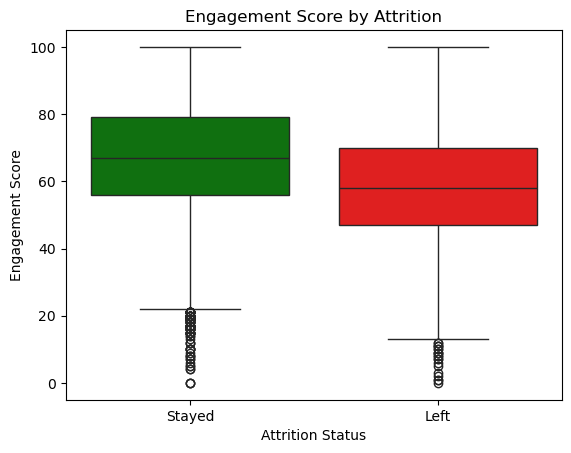

In [31]:
sns.boxplot(x='attrition', y='engagement_score', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("Engagement Score by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Engagement Score")
plt.show()

**Insight:**

### 3. ค่าตอบแทน Salary vs Market กับ Attrition

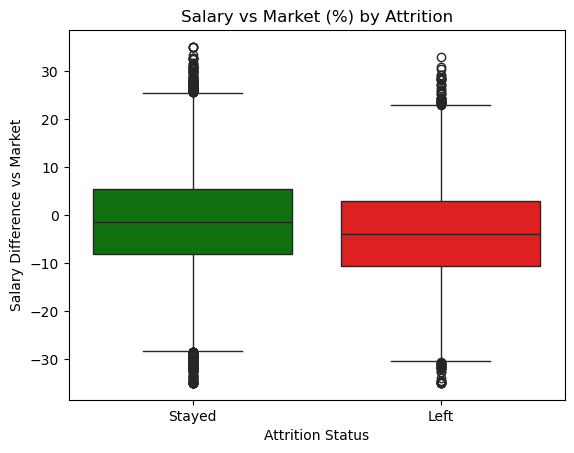

In [32]:
sns.boxplot(x='attrition', y='salary_vs_market_pct', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Salary vs Market (%) by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Salary Difference vs Market")
plt.show()

**Insight:**

### 4. carrer_growth_score

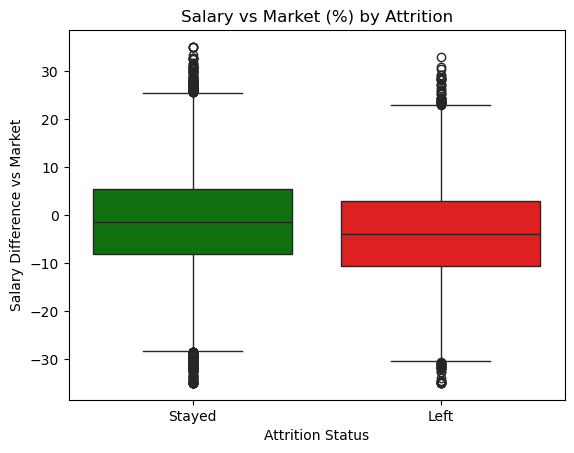

In [33]:
sns.boxplot(x='attrition', y='salary_vs_market_pct', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Salary vs Market (%) by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Salary Difference vs Market")
plt.show()

**Insight:** 

### 5.Tenure (อายุงาน) กับ Attrition 

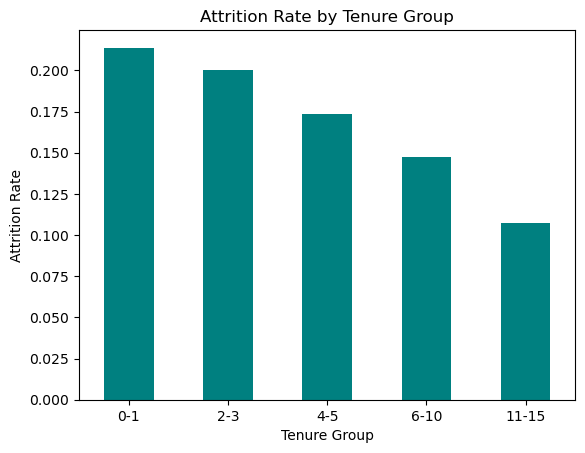

In [34]:
df['tenure_bin'] = pd.cut(df['tenure_years'], bins=[0,1,3,5,10,15],labels=['0-1','2-3','4-5','6-10','11-15'])
df.groupby(df['tenure_bin'], observed=True)['attrition'].mean().plot(kind='bar', color='teal')
plt.title("Attrition Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=0)
plt.show()

**Insight:**

## สรุปผล EDA

**ปัจจัยที่สัมพันธ์กับ Attrition**



In [35]:
dt = pd.read_csv("../data/data_dictionary.csv")

In [36]:
dt

,column,type,description
0,employee_id,string,Unique employee id
1,age,int,Age in years
2,generation,string,Gen Z / Millennial / Gen X / Boomer (derived f...
3,gender,string,Male / Female / Other
4,department,string,"Department (Engineering, Product, Sales, Opera..."
5,job_level,string,Junior / Mid / Senior / Lead / Manager / Director
6,is_manager,int,1 if a people-manager role (Lead/Manager/Direc...
7,tenure_years,float,Years at the company
8,salary_usd,int,Annual salary (USD)
9,salary_vs_market_pct,float,"Salary vs market benchmark (%), negative = und..."
